### About the Data:
age: age of the insured person (numeric)                                          
sex: gender of the insured person (categorical: male/female)                                     
bmi: body mass index of the insured person (numeric)                                               
children: number of children covered by the insurance plan (numeric)                                  
smoker: whether or not the insured person is a smoker (categorical: yes/no)                                  
region: region where the insured person resides (categorical: northeast/northwest/southeast/southwest)                                            
charges: the insurance charges/costs billed to the insured person (numeric)                                                         

In [127]:
# Import Necessary Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Import Data

In [128]:
medical_df = pd.read_csv('medical_insurance.csv')

### 2. Cleaning the data

In [129]:
medical_df.shape

(1338, 7)

In [130]:
medical_df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [131]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [132]:
# Check the unique values of each column to identify inconsistencies, invalid entries, missing values, duplicate categories, and formatting issues.

# medical_df['age'].value_counts()
# medical_df['sex'].value_counts()
# medical_df['bmi'].value_counts()
medical_df['children'].value_counts()
# medical_df['smoker'].value_counts()
# medical_df['region'].value_counts()
# medical_df['charges'].value_counts()

# No anomalies were found in any column, so no data cleaning is required.

0    574
1    324
2    240
3    157
4     25
5     18
Name: children, dtype: int64

### 3. Exploratory Data Analysis

#### i. Identifying outliers

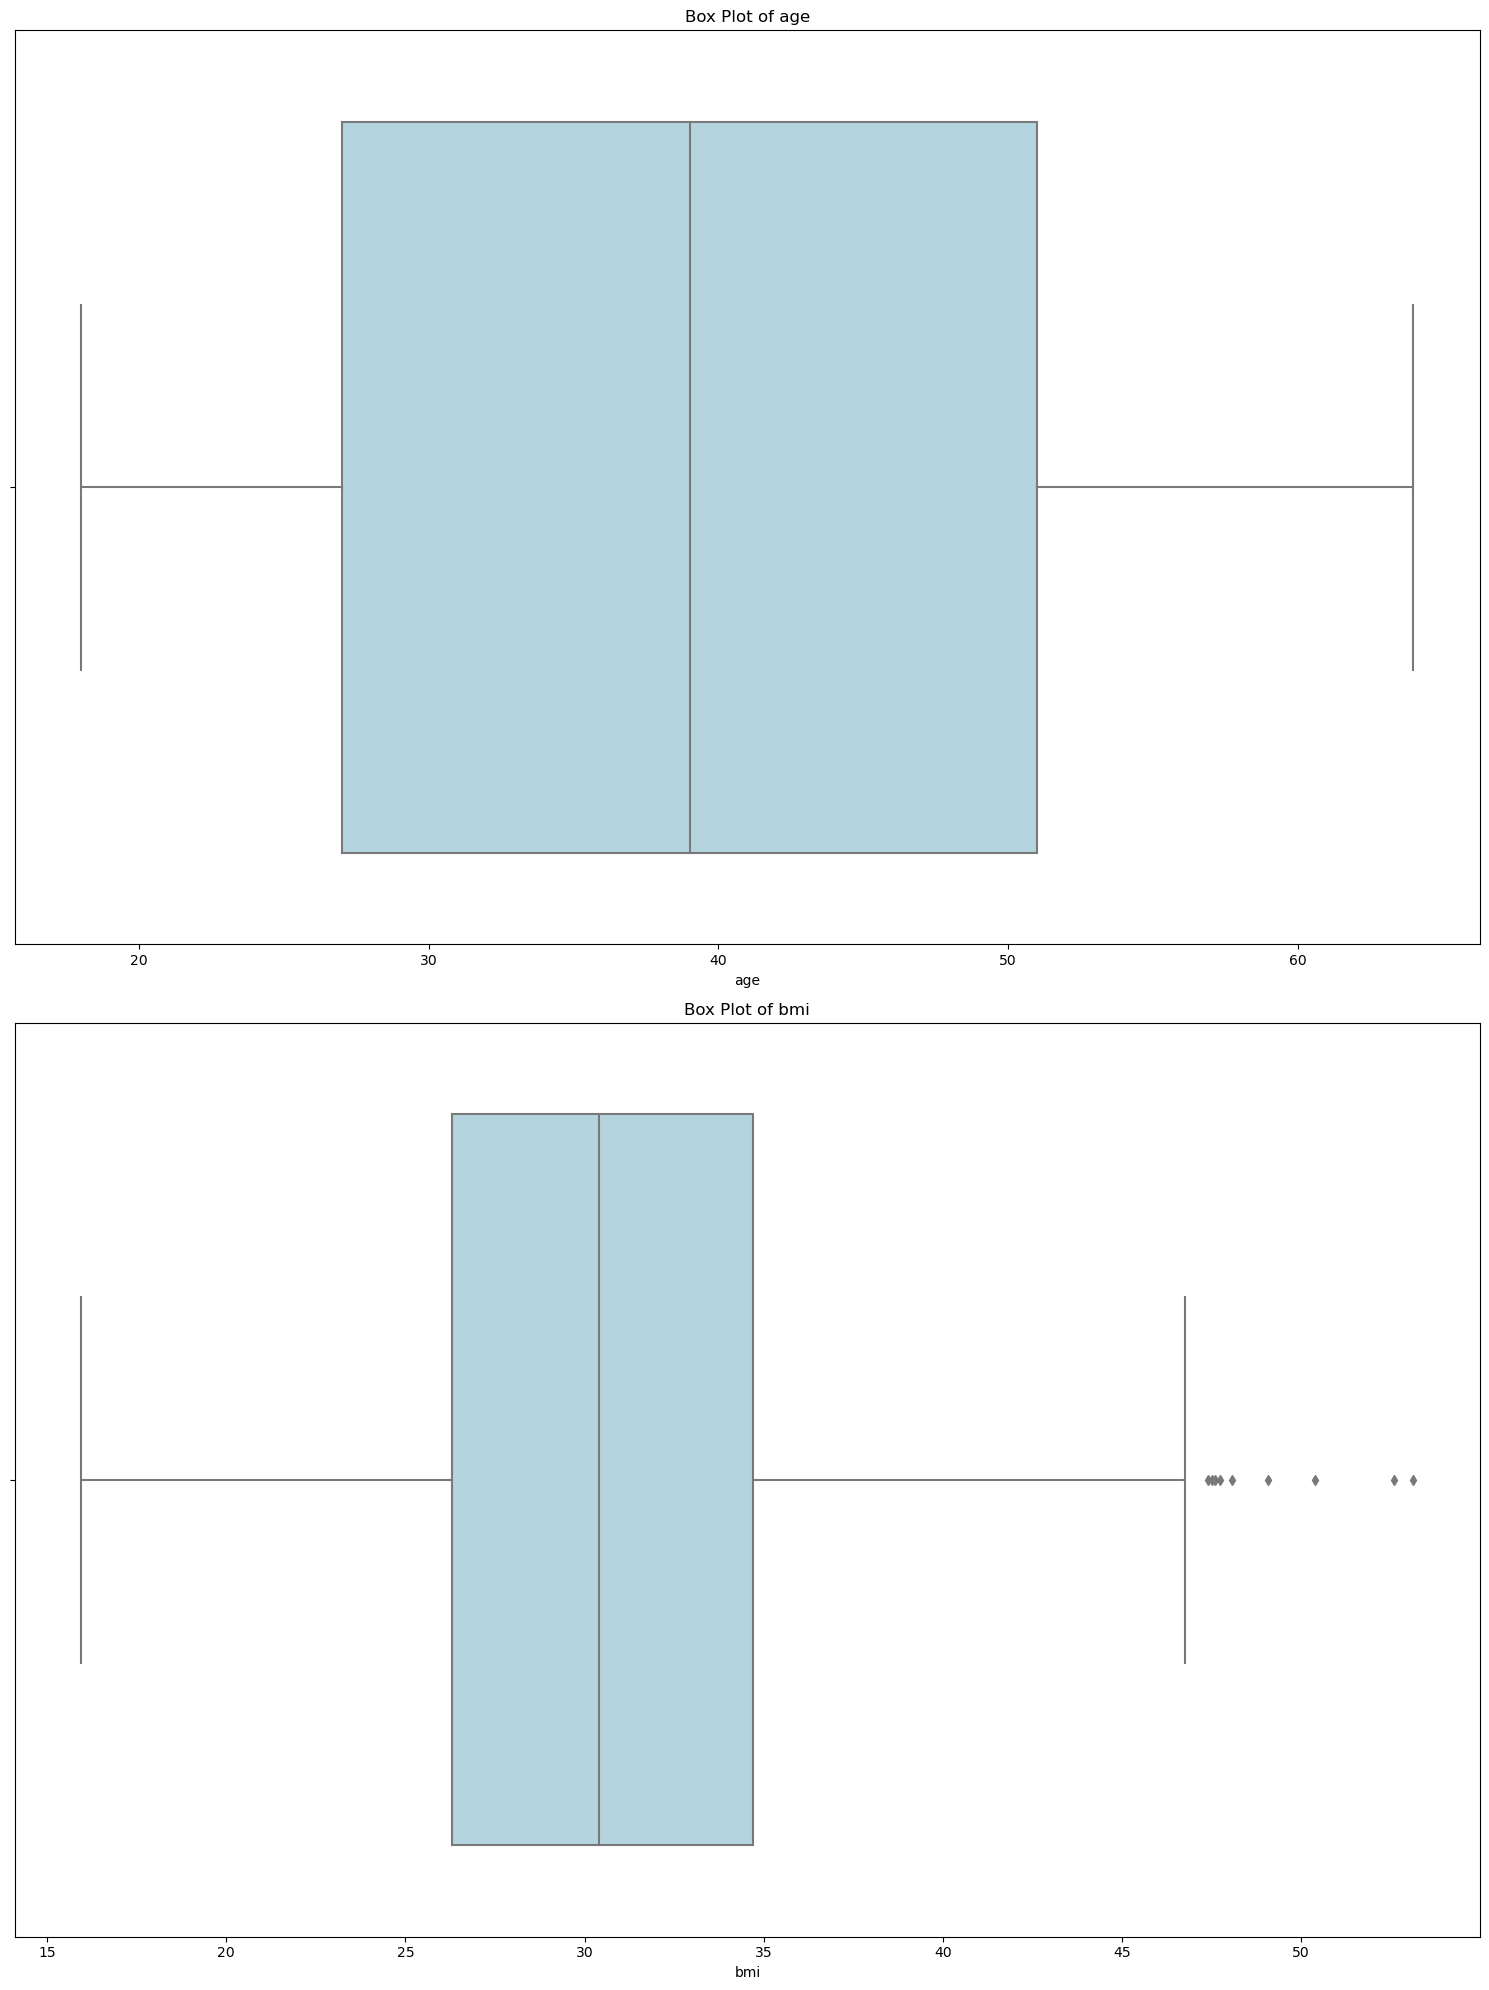

In [133]:
# Select numerical columns
numeric_columns = ["age","bmi"]
plt.figure(figsize=(15, 20))

#iterating over each column and create a bar plot
for i,col in enumerate(numeric_columns):
    plt.subplot(len(numeric_columns), 1, i+1)
    sns.boxplot(x=medical_df[col], color='lightblue')
    plt.title(f"Box Plot of {col}")
    plt.xlabel(col)
 
plt.tight_layout()    
plt.show()

##### Remove outliers

In [134]:
print("Original shape:", medical_df.shape)
# Select numerical columns
numeric_columns = ["age","bmi"]

# Function to remove outliers using IQR
def remove_outliers(data, cols):
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        data = data[(data[col] >= lower_limit) & (data[col] <= upper_limit)]
    return data

# Apply function
medical_df= remove_outliers(medical_df, numeric_columns)

print("After removing outliers:", medical_df.shape)
medical_cleaned_data = medical_df.copy()

Original shape: (1338, 7)
After removing outliers: (1329, 7)


<Figure size 300x300 with 0 Axes>

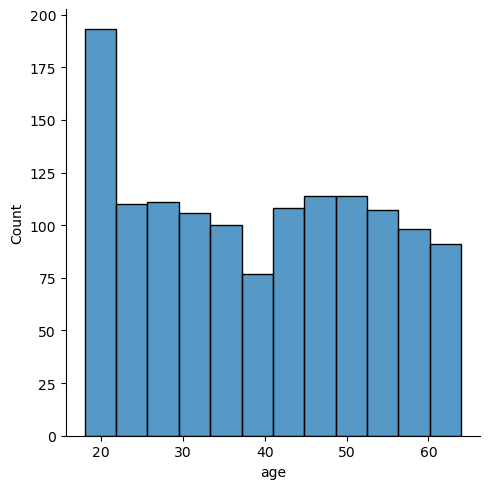

In [135]:
plt.figure(figsize=(3,3))
sns.displot(data=medical_df,x='age')
plt.show()

<Figure size 300x300 with 0 Axes>

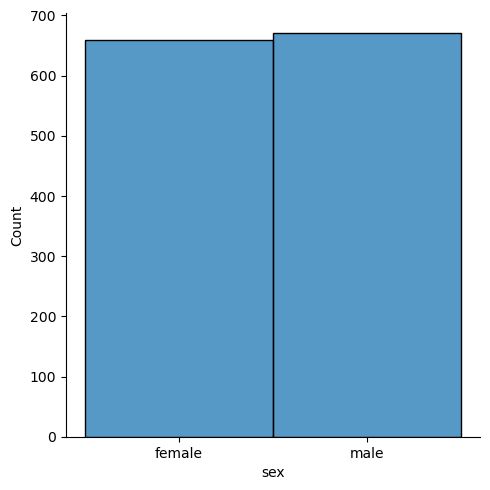

In [136]:
plt.figure(figsize=(3,3))
sns.displot(data=medical_df,x='sex',kind='hist')
plt.show()

<Figure size 400x400 with 0 Axes>

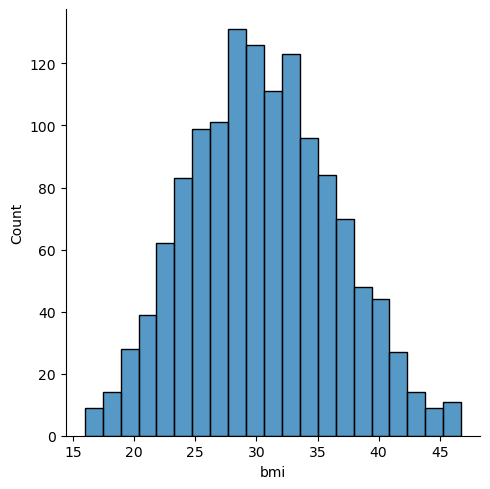

In [137]:
plt.figure(figsize=(4,4))
sns.displot(data=medical_df,x='bmi')
plt.xlabel('bmi') 
plt.ylabel('Count')
plt.show()

In [138]:
medical_df['children'].value_counts()

0    571
1    320
2    238
3    157
4     25
5     18
Name: children, dtype: int64

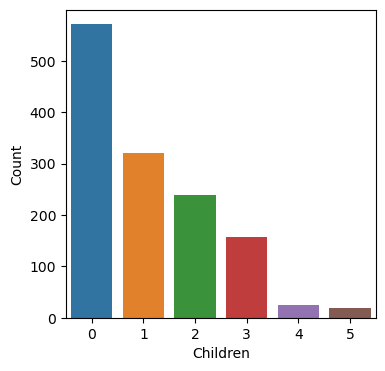

In [139]:
plt.figure(figsize=(4,4))
sns.countplot(medical_df,x='children')
plt.xlabel('Children') 
plt.ylabel('Count')
plt.show()

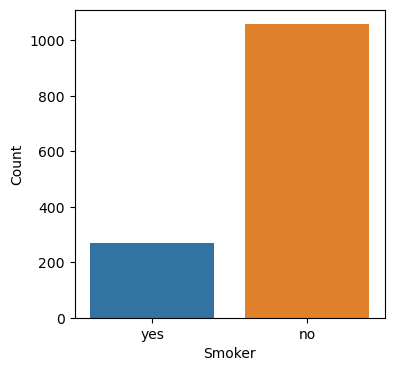

In [140]:
plt.figure(figsize=(4,4))
sns.countplot(data=medical_df,x='smoker')
plt.xlabel('Smoker') 
plt.ylabel('Count')
plt.show()

In [141]:
medical_df['region'].value_counts()

southeast    357
northwest    325
southwest    324
northeast    323
Name: region, dtype: int64

### 4. Seperate Dependant and Independant Feature

In [142]:
x = medical_df.drop('charges',axis=1)
y = medical_df['charges']

### 5. Train Test Split

In [143]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

### 6. Preprocessing-convert categorical variables into numerical values

In [144]:
x_train.head(1)

,age,sex,bmi,children,smoker,region
1186,20,male,35.625,3,yes,northwest


In [145]:
scale_columns = ["age", "bmi","children"]
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
column_transformer = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), scale_columns),
        ('ohe', OneHotEncoder(sparse=False),['sex','smoker','region'])
        ]
)


### 7. Train ML Models

In [146]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor,ExtraTreesRegressor
from xgboost import XGBRegressor


lr = LinearRegression()
lr_lasso = Lasso()
lr_ridge = Ridge()
dtr=DecisionTreeRegressor()
knr=KNeighborsRegressor()
svr=SVR()
rfr=RandomForestRegressor()
gbr=GradientBoostingRegressor()
abr=AdaBoostRegressor()
etr=ExtraTreesRegressor()
xgb=XGBRegressor()
r_names={'lr':lr,'lr_lasso':lr_lasso,'lr_ridge':lr_ridge,'dtr':dtr,'knr':knr,'svr':svr,'rfr':rfr,'gbr':gbr,'abr':abr,'etr':etr,'xgb':xgb}

### 8. Model Evaluation

In [147]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def get_metrics(r,x_train,y_train,x_test,y_test):
     pipe = Pipeline([('CT', column_transformer),('Model',r)])
     pipe.fit(x_train,y_train)
     y_pred = pipe.predict(x_test)
    
     MSE = mean_squared_error(y_test, y_pred)
     RMSE = np.sqrt(MSE)
     MAE = mean_absolute_error(y_test, y_pred)
     R2 = r2_score(y_test, y_pred)
     return MSE,RMSE,MAE,R2
 
 
all_MSE = []
all_RMSE = []
all_MAE = []
all_R2 = []
for name,r in r_names.items():
    current_MSE,current_RMSE,current_MAE,current_R2 = get_metrics(r,x_train,y_train,x_test,y_test)
    
    all_MSE.append(current_MSE)
    all_RMSE.append(current_RMSE)
    all_MAE.append(current_MAE)
    all_R2.append(current_R2) 
metrics_df = pd.DataFrame({'Algorithm':r_names.keys(),'MSE':all_MSE,'RMSE':all_RMSE,'MAE':all_MAE,'R2':all_R2}).sort_values('R2',ascending=False)
metrics_df

c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoder

,Algorithm,MSE,RMSE,MAE,R2
7,gbr,1.882304e+07,4338.552672,2226.816670,0.883591
6,rfr,2.443017e+07,4942.688228,2578.073095,0.848914
10,xgb,2.638326e+07,5136.463716,2908.881690,0.836835
9,etr,2.784975e+07,5277.286031,2519.734785,0.827766
4,knr,2.936095e+07,5418.574468,3143.433070,0.818420
8,abr,3.161375e+07,5622.610702,4702.308400,0.804488
1,lr_lasso,3.458510e+07,5880.909599,4145.217404,0.786112
0,lr,3.459010e+07,5881.334864,4145.662406,0.786081
2,lr_ridge,3.459892e+07,5882.084520,4150.864799,0.786026
3,dtr,4.920179e+07,7014.398883,3387.798769,0.695716


### 9. After Comparison-Selected Model

In [148]:
# LinearRegression gives overall best result
scale_columns = ["age", "bmi", "children"]
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
column_transformer = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), scale_columns),
        ('ohe', OneHotEncoder(sparse=False),['sex','smoker','region'])
        ]
) 
from sklearn.linear_model import LinearRegression
lr= LinearRegression()
from sklearn.pipeline import Pipeline
pipe = Pipeline([('CT', column_transformer),('Model', lr)])
pipe.fit(x_train,y_train)



c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Pipeline(steps=[('CT',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('ohe',
                                                  OneHotEncoder(sparse=False),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('Model', LinearRegression())])

### 10. Prediction System

In [149]:
# Input data as dictionary with column names
input_data = {
    'age': 25,
    'sex': "female",
    'bmi': 40.020,
    'children': 5,
    'smoker': "no",
    'region': "southeast"
}

# Convert to DataFrame (1 row, with column names)
input_df = pd.DataFrame([input_data])

# Predict using pipeline
prediction = pipe.predict(input_df)
print(prediction)

[9550.60627306]


In [150]:
import pickle
pickle.dump(pipe,open('model.pkl','wb'))

In [151]:
# import pickle
# pickle.load(open('model.pkl','rb'))